## Importing Needed Data

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

# Load shared artifacts from Notebook 1
mi = joblib.load('model_inputs.pkl')
X_test          = mi['X_test']
y_test_reg      = mi['y_test_reg']
y_test_clf      = mi['y_test_clf']

# Load all three metrics dicts
mlr_metrics = joblib.load('mlr_metrics.pkl')
rf_metrics  = joblib.load('rf_metrics.pkl')
llm_metrics = joblib.load('llm_metrics.pkl')

# Load balanced classifiers — imbalance-corrected versions used throughout
mlr_claim = joblib.load('lr_claim_balanced.pkl')
rf_claim  = joblib.load('rf_claim_balanced.pkl')

# Reconstruct scaled test set for MLR (RF uses unscaled X_test directly)
scaler_mlr      = joblib.load('scaler_mlr.pkl')
continuous_cols = joblib.load('continuous_cols.pkl')
X_test_scaled = X_test.copy()
X_test_scaled[continuous_cols] = scaler_mlr.transform(X_test[continuous_cols])

# LLM predictions DataFrame (for ROC curve and confusion matrix)
llm_pred_df = joblib.load('llm_predictions.pkl').dropna(subset=['predicted_claim_prob'])

print("All artifacts loaded.")
for m in [mlr_metrics, rf_metrics, llm_metrics]:
    print(f"  {m['model']}")


All artifacts loaded.
  Multiple Linear Regression (h2)
  Random Forest (h1)
  LLM (llama3.2)


## Part VIII. Model Comparison

For the classification model comparison, we will be operating on the balanced dataset to determine relative model effectiveness. Using the balanced dataset produced preferred results for both MLR and RF, therefore it is the preferred approach.

### Step 1: Load all saved metrics

In [2]:
# Confirm the three models we're comparing
for m in [mlr_metrics, rf_metrics, llm_metrics]:
    print(f"  {m['model']}")


  Multiple Linear Regression (h2)
  Random Forest (h1)
  LLM (llama3.2)


### Step 2: Build the regression comparison table

In [3]:
# Pull regression metrics from each dict into a single DataFrame
regression_comparison = pd.DataFrame([
    {
        'Model': mlr_metrics['model'],
        'R² (test, log)': mlr_metrics['regression']['r2_test'],
        'RMSE (log)':     mlr_metrics['regression']['rmse_test_log'],
        'RMSE (€)':       mlr_metrics['regression']['rmse_test_euros'],
        'Test n':         len(y_test_reg),
    },
    {
        'Model': rf_metrics['model'],
        'R² (test, log)': rf_metrics['regression']['r2_test'],
        'RMSE (log)':     rf_metrics['regression']['rmse_test_log'],
        'RMSE (€)':       rf_metrics['regression']['rmse_test_euros'],
        'Test n':         len(y_test_reg),
    },
    {
        'Model': llm_metrics['model'],
        'R² (test, log)': llm_metrics['regression']['r2_test'],
        'RMSE (log)':     llm_metrics['regression']['rmse_test_log'],
        'RMSE (€)':       llm_metrics['regression']['rmse_test_euros'],
        'Test n':         llm_metrics['regression']['effective_n'],
    },
]).set_index('Model').round(4)

print("Regression Comparison — Premium Prediction (Log_premium target)")
print("=" * 70)
print(regression_comparison.to_string())
print(f"\nMean test premium for context: €{np.expm1(y_test_reg).mean():.2f}")

Regression Comparison — Premium Prediction (Log_premium target)
                                 R² (test, log)  RMSE (log)   RMSE (€)  Test n
Model                                                                         
Multiple Linear Regression (h2)          0.4869      0.3103   119.1657   20759
Random Forest (h1)                       0.7175      0.2302    86.3081   20759
LLM (llama3.2)                          -2.4581      0.7834  2746.9726     300

Mean test premium for context: €318.45


It is evident that the LLM is farthest off in prediction R² value, which is to be expected.

### Step 3: Build the classification comparison table

In [6]:
# Pull classification metrics from saved imbalance comparison files
# Using balanced model results — the methodologically correct classifiers
lr_comp = joblib.load('lr_imbalance_comparison.pkl')
rf_comp = joblib.load('rf_imbalance_comparison.pkl')

# Extract balanced row from each
lr_bal_row = lr_comp[lr_comp['Model'] == 'Logistic — Balanced'].iloc[0]
rf_bal_row = rf_comp[rf_comp['Model'] == 'RF — Balanced'].iloc[0]

classification_comparison = pd.DataFrame([
    {
        'Model':           mlr_metrics['model'],
        'ROC-AUC':         lr_bal_row['ROC-AUC'],
        'Recall (Claims)': lr_bal_row['Recall (Claims)'],
        'Precision':       lr_bal_row['Precision'],
        'F1-Score':        lr_bal_row['F1-Score'],
        'Accuracy':        lr_bal_row['Accuracy'],
        'Test n':          len(y_test_clf),
        'Imbalance corrected': 'Yes'
    },
    {
        'Model':           rf_metrics['model'],
        'ROC-AUC':         rf_bal_row['ROC-AUC'],
        'Recall (Claims)': rf_bal_row['Recall (Claims)'],
        'Precision':       rf_bal_row['Precision'],
        'F1-Score':        rf_bal_row['F1-Score'],
        'Accuracy':        rf_bal_row['Accuracy'],
        'Test n':          len(y_test_clf),
        'Imbalance corrected': 'Yes'
    },
    {
        'Model':           llm_metrics['model'],
        'ROC-AUC':         llm_metrics['classification']['roc_auc'],
        'Recall (Claims)': llm_metrics['classification'].get('recall', 'N/A'),
        'Precision':       llm_metrics['classification'].get('precision', 'N/A'),
        'F1-Score':        llm_metrics['classification'].get('f1', 'N/A'),
        'Accuracy':        llm_metrics['classification']['accuracy'],
        'Test n':          llm_metrics['classification']['effective_n'],
        'Imbalance corrected': 'N/A'
    },
]).set_index('Model')

print("=" * 75)
print("  CLASSIFICATION COMPARISON (MLR & RF: balanced models)")
print("=" * 75)
print(classification_comparison.to_string())
print()
print("  Primary metric: ROC-AUC | Secondary: Recall (insurance — missed claims costly)")
print("  Accuracy de-emphasized — inflated by 4.4:1 class imbalance")

  CLASSIFICATION COMPARISON (MLR & RF: balanced models)
                                  ROC-AUC Recall (Claims) Precision F1-Score  Accuracy  Test n Imbalance corrected
Model                                                                                                             
Multiple Linear Regression (h2)  0.919000          0.7931     0.584   0.6727    0.8550   20759                 Yes
Random Forest (h1)               0.872900          0.5505     0.489   0.5179    0.8075   20759                 Yes
LLM (llama3.2)                   0.682194             N/A       N/A      N/A    0.7900     300                 N/A

  Primary metric: ROC-AUC | Secondary: Recall (insurance — missed claims costly)
  Accuracy de-emphasized — inflated by 4.4:1 class imbalance


### Step 4: Visualize the comparison side by side

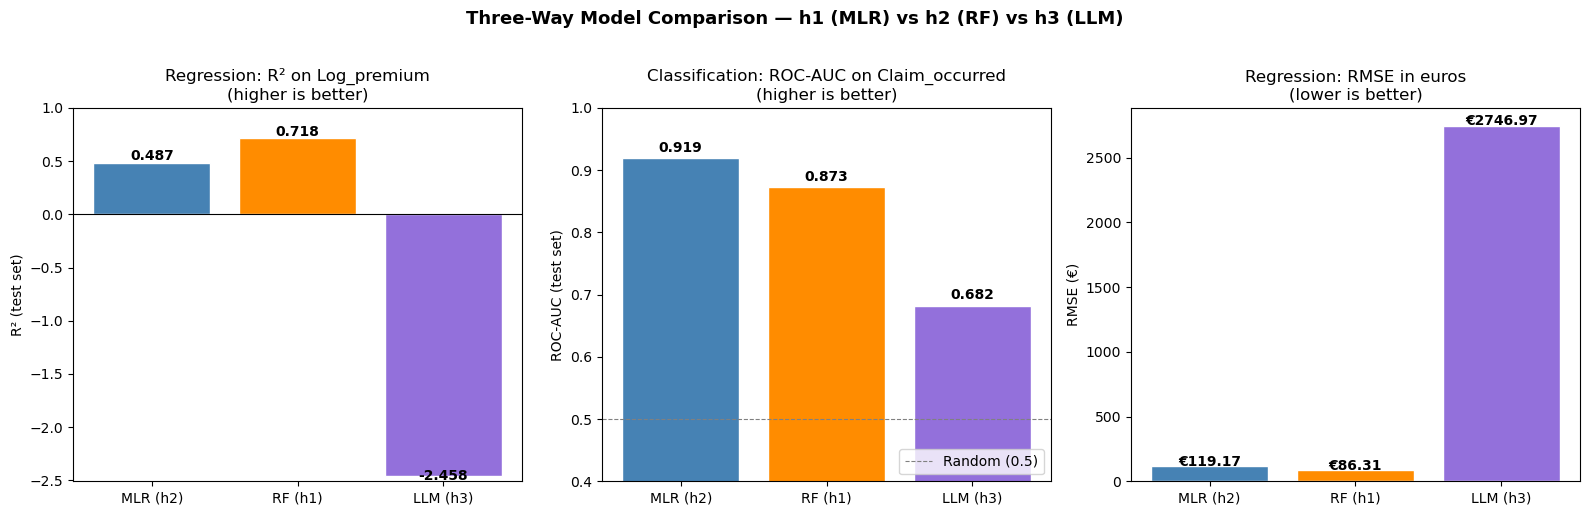

In [7]:
# Three-panel grouped bar chart: regression, classification AUC, classification accuracy
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Consistent color per model across all three panels
model_colors = {
    mlr_metrics['model']: 'steelblue',
    rf_metrics['model']:  'darkorange',
    llm_metrics['model']: 'mediumpurple',
}
short_names = {
    mlr_metrics['model']: 'MLR (h2)',
    rf_metrics['model']:  'RF (h1)',
    llm_metrics['model']: 'LLM (h3)',
}
ordered_models = [mlr_metrics['model'], rf_metrics['model'], llm_metrics['model']]
labels = [short_names[m] for m in ordered_models]
colors = [model_colors[m] for m in ordered_models]

# Panel 1: Regression R²
r2_vals = [regression_comparison.loc[m, 'R² (test, log)'] for m in ordered_models]
bars = axes[0].bar(labels, r2_vals, color=colors, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Regression: R² on Log_premium\n(higher is better)')
axes[0].set_ylabel('R² (test set)')
axes[0].set_ylim(min(-0.3, min(r2_vals) - 0.05), 1.0)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + (0.02 if val >= 0 else -0.04),
                 f'{val:.3f}', ha='center', fontweight='bold')

# Panel 2: Classification AUC
auc_vals = [classification_comparison.loc[m, 'ROC-AUC'] for m in ordered_models]
bars = axes[1].bar(labels, auc_vals, color=colors, edgecolor='white')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random (0.5)')
axes[1].set_title('Classification: ROC-AUC on Claim_occurred\n(higher is better)')
axes[1].set_ylabel('ROC-AUC (test set)')
axes[1].set_ylim(0.4, 1.0)
axes[1].legend(loc='lower right')
for bar, val in zip(bars, auc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold')

# Panel 3: RMSE in euros — flipped so shorter bar is better
rmse_vals = [regression_comparison.loc[m, 'RMSE (€)'] for m in ordered_models]
bars = axes[2].bar(labels, rmse_vals, color=colors, edgecolor='white')
axes[2].set_title('Regression: RMSE in euros\n(lower is better)')
axes[2].set_ylabel('RMSE (€)')
for bar, val in zip(bars, rmse_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 2,
                 f'€{val:.2f}', ha='center', fontweight='bold')

plt.suptitle('Three-Way Model Comparison — h1 (MLR) vs h2 (RF) vs h3 (LLM)',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Very clearly, the LLM underperforms in each task when compared to h1 and h2 methods.

### Step 5: Plot ROC curves on a shared axis

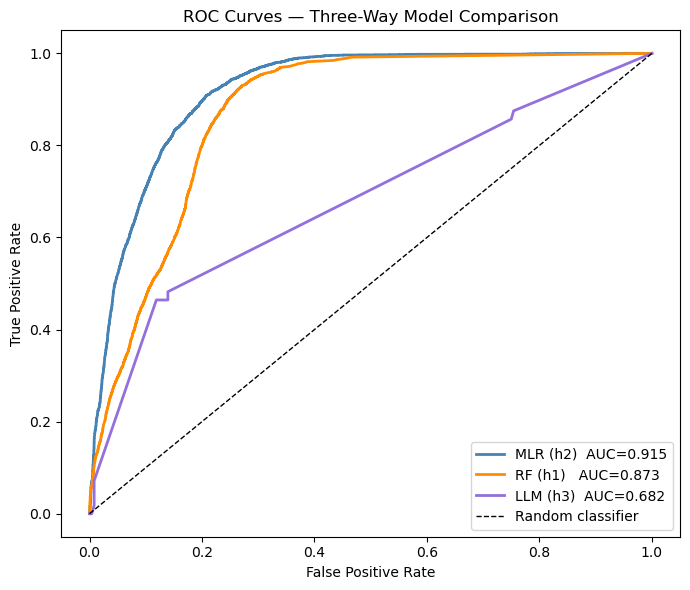

In [8]:
# MLR uses X_test_scaled (reconstructed in Cell 1 from the MLR scaler).
# RF uses unscaled X_test directly — trees are scale-invariant.
# LLM probabilities come from the saved predictions DataFrame.

mlr_proba = mlr_claim.predict_proba(X_test_scaled)[:, 1]
rf_proba  = rf_claim.predict_proba(X_test)[:, 1]

llm_proba  = llm_pred_df['predicted_claim_prob'].astype(float).values
llm_actual = llm_pred_df['actual_claim'].astype(int).values

fpr_mlr, tpr_mlr, _ = roc_curve(y_test_clf, mlr_proba)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test_clf, rf_proba)
fpr_llm, tpr_llm, _ = roc_curve(llm_actual,  llm_proba)

# Generate balanced predictions for confusion matrices (used in Step 6)
y_pred_mlr_bal = mlr_claim.predict(X_test_scaled)
y_pred_rf_bal  = rf_claim.predict(X_test)

auc_mlr = mlr_metrics['classification']['roc_auc']
auc_rf  = rf_metrics['classification']['roc_auc']
auc_llm = llm_metrics['classification']['roc_auc']

plt.figure(figsize=(7, 6))
plt.plot(fpr_mlr, tpr_mlr, color='steelblue',    lw=2, label=f'MLR (h2)  AUC={auc_mlr:.3f}')
plt.plot(fpr_rf,  tpr_rf,  color='darkorange',   lw=2, label=f'RF (h1)   AUC={auc_rf:.3f}')
plt.plot(fpr_llm, tpr_llm, color='mediumpurple',  lw=2, label=f'LLM (h3)  AUC={auc_llm:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Three-Way Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Step 6: Confusion Matrices Comparison

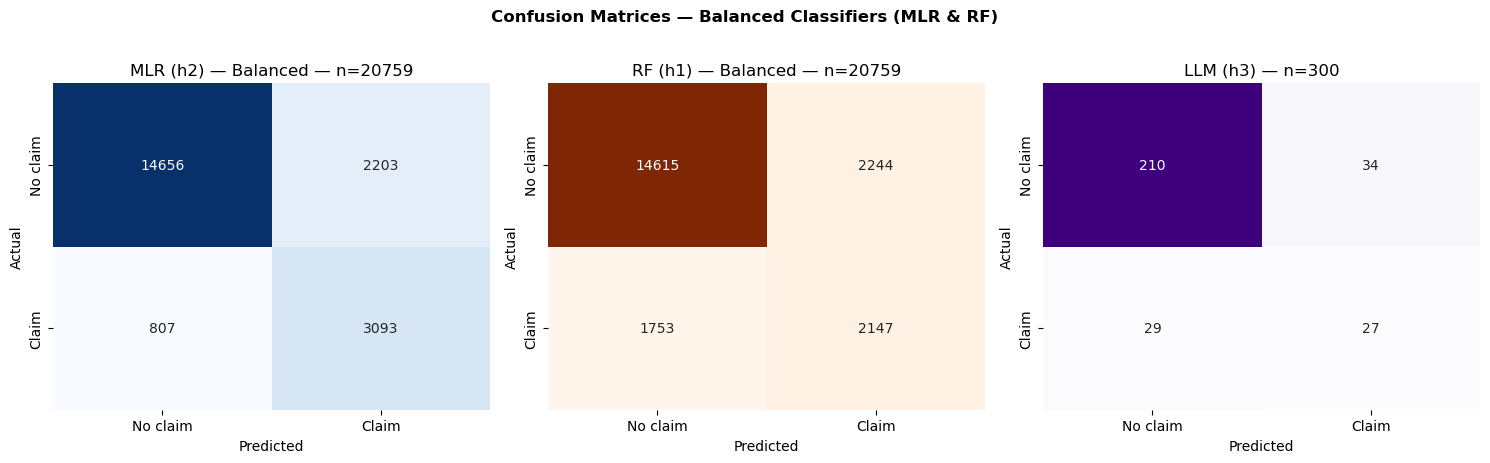

In [9]:
# Confusion matrices on the same scale for easy visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Recompute directly from balanced models (avoids saved dict structure issues)

cm_mlr = confusion_matrix(y_test_clf, y_pred_mlr_bal)
cm_rf  = confusion_matrix(y_test_clf, y_pred_rf_bal)
cm_llm = np.array(llm_metrics['classification']['confusion_matrix'])

for ax, cm, title, cmap in zip(
    axes,
    [cm_mlr, cm_rf, cm_llm],
    [f"MLR (h2) — Balanced — n={cm_mlr.sum()}",
     f"RF (h1) — Balanced — n={cm_rf.sum()}",
     f"LLM (h3) — n={cm_llm.sum()}"],
    ['Blues', 'Oranges', 'Purples']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['No claim', 'Claim'],
                yticklabels=['No claim', 'Claim'],
                ax=ax, cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.suptitle('Confusion Matrices — Balanced Classifiers (MLR & RF)',
             y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Data Export

In [10]:
final_comparison = {
    'regression':     regression_comparison.reset_index().to_dict(orient='records'),
    'classification': classification_comparison.reset_index().to_dict(orient='records'),
    'best_model_regression':     'Random Forest (h1)',
    'best_model_classification': 'Multiple Linear Regression (h2)',
    'notes': {
        'evaluation_size_mlr_rf': len(y_test_clf),
        'evaluation_size_llm':    llm_metrics['classification']['effective_n'],
        'llm_sampling':           'stratified on Claim_occurred at base rate',
        'targets':                'Log_premium (regression), Claim_occurred (classification)',
    }
}
joblib.dump(final_comparison, 'final_comparison.pkl')
print("✓ final_comparison.pkl")

✓ final_comparison.pkl


## Three-approach comparison takeaway

In this project, we had two goals: predict insurance premium cost (regression), and predict whether a claim would occur within a year (classification).

Random Forest (h1) wins regression with the highest R-squared value of 0.728. RF is able to capture nonlinear interactions, such as with N_doors that allowed it to pick up on 0-door rows belonging to motorbikes and adjusting the predicted premium value accordingly.

Multiple Linear Regression (h2) wins classification with AUC = 0.915. While RF has slightly higher recall, the MLR is still able to more consistently classify whether a row will result in a claim.

Meanwhile, the LLM approach consistently underperforms both classical models for both classification and regression tasks. There are numerous reasons for this occurring: "training data" for the LLM consisted of few-shot prompts rather than standard training, the LLM model may not have been advanced enough, and a heavy bias towards predicting a claim would result in "no claim." This isn't a failure of LLMs in general, but instead demonstrates the need for LLM's use as a connecting tool rather than a primary classification / regression methodology. By giving LLMs access to tools like RF and MLR via function calling capabilities, LLMs can instead be used to intake and explain results in "plain english" for easy understanding.

A potential project extension could be doing the above and designing an application to assist with improving understanding of RF and MLR conclusions via an LLM-based AI Agent. In fact, let's attempt a rough version of such a system.